In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)


In [40]:
trades = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

print("Trades Dataset Shape:", trades.shape)
display(trades.head())
print("Fear & Greed Dataset Shape:", fear.shape)
display(fear.head())


Trades Dataset Shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Fear & Greed Dataset Shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [15]:
print("\n===== TRADES DATASET =====")
print(trades.info())

print("\nMissing Values:")
print(trades.isnull().sum())

print("\nDuplicates:")
print(trades.duplicated().sum())


print("\n===== FEAR & GREED DATASET =====")
print(fear.info())

print("\nMissing Values:")
print(fear.isnull().sum())

print("\nDuplicates:")
print(fear.duplicated().sum())


===== TRADES DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121129 entries, 0 to 121128
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           121129 non-null  object 
 1   Coin              121129 non-null  object 
 2   Execution Price   121129 non-null  float64
 3   Size Tokens       121129 non-null  float64
 4   Size USD          121129 non-null  float64
 5   Side              121129 non-null  object 
 6   Timestamp IST     121129 non-null  object 
 7   Start Position    121129 non-null  float64
 8   Direction         121129 non-null  object 
 9   Closed PnL        121128 non-null  float64
 10  Transaction Hash  121128 non-null  object 
 11  Order ID          121128 non-null  float64
 12  Crossed           121128 non-null  object 
 13  Fee               121128 non-null  float64
 14  Trade ID          121128 non-null  float64
 15  Timestamp         121128 non-null  float

In [16]:
summary = pd.DataFrame({
    "Dataset": ["Trades", "Fear & Greed"],
    "Rows": [trades.shape[0], fear.shape[0]],
    "Columns": [trades.shape[1], fear.shape[1]],
    "Duplicates": [
        trades.duplicated().sum(),
        fear.duplicated().sum()
    ]
})

display(summary)

,Dataset,Rows,Columns,Duplicates
0,Trades,121129,16,0
1,Fear & Greed,2644,4,0


In [17]:
trades["Timestamp"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms"
)

trades["Date"] = trades["Timestamp"].dt.date


fear["date"] = pd.to_datetime(
    fear["date"]
)

fear["Date"] = fear["date"].dt.date


In [18]:
merged = pd.merge(
    trades,
    fear[["Date", "value", "classification"]],
    on="Date",
    how="left"
)

print("Merged Shape:", merged.shape)

display(merged.head())


Merged Shape: (121129, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed


In [35]:
# Daily PnL
daily_pnl = (
    merged.groupby("Date")["Closed PnL"]
    .sum()
    .reset_index()
)

# Number of trades per day
daily_trades = (
    merged.groupby("Date")
    .size()
    .reset_index(name="Trades")
)

# Win column
merged["Win"] = np.where(
    merged["Closed PnL"] > 0,
    1,
    0
)

# Win rate per account
win_rate = (
    merged.groupby("Account")["Win"]
    .mean()
    .mul(100)
    .reset_index(name="Win Rate")
)

# Average trade size
trade_size = (
    merged.groupby("Account")["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size")
)



# Long/Short counts
long_short = (
    merged["Side"]
    .value_counts()
    .reset_index()
)

long_short.columns = ["Position", "Count"]

# Sentiment column
merged["Sentiment"] = np.where(
    merged["value"] >= 50,
    "Greed",
    "Fear"
)
daily_pnl_account = (
    merged.groupby(["Account", "Date"])["Closed PnL"]
    .sum()
    .reset_index()
)


# Average PnL by sentiment
sentiment_pnl = (
    merged.groupby("Sentiment")["Closed PnL"]
    .mean()
    .reset_index()
)

# Number of trades by sentiment
sentiment_trades = (
    merged.groupby("Sentiment")
    .size()
    .reset_index(name="Trades")
)

In [20]:
sentiment_trades = (
    merged
    .groupby("Sentiment")
    .size()
    .reset_index(name="Trades")
)

display(sentiment_trades)

,Sentiment,Trades
0,Fear,92414
1,Greed,28715


In [24]:
import os

os.makedirs("outputs", exist_ok=True)

In [25]:
daily_pnl.to_csv(
    "daily_pnl.csv",
    index=False
)

daily_pnl_account.to_csv(
    "outputs/daily_pnl_account.csv",
    index=False
)

daily_trades.to_csv(
    "outputs/daily_trades.csv",
    index=False
)

win_rate.to_csv(
    "outputs/win_rate.csv",
    index=False
)

trade_size.to_csv(
    "outputs/trade_size.csv",
    index=False
)




sentiment_pnl.to_csv(
    "outputs/sentiment_pnl.csv",
    index=False
)

merged.to_csv(
    "outputs/merged_dataset.csv",
    index=False
)

print("Part A completed successfully.")

Part A completed successfully.


# Part B — **Analysis**

,Sentiment,Closed PnL
0,Fear,58.471212
1,Greed,73.125274


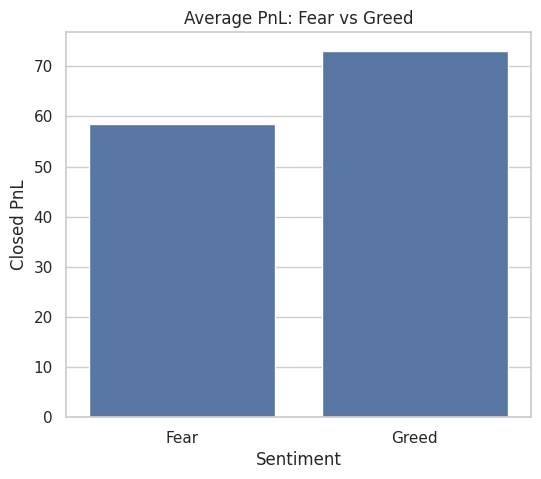

In [26]:
# 1. Does performance differ between Fear vs Greed days?
'''  Average PnL '''
sentiment_pnl = (
    merged.groupby("Sentiment")["Closed PnL"]
    .mean()
    .reset_index()
)

display(sentiment_pnl)

plt.figure(figsize=(6,5))
sns.barplot(
    data=sentiment_pnl,
    x="Sentiment",
    y="Closed PnL"
)
plt.title("Average PnL: Fear vs Greed")
plt.savefig("outputs/avg_pnl_sentiment.png",dpi=300)
plt.show()


,Sentiment,Win Rate
0,Fear,41.183154
1,Greed,40.160195


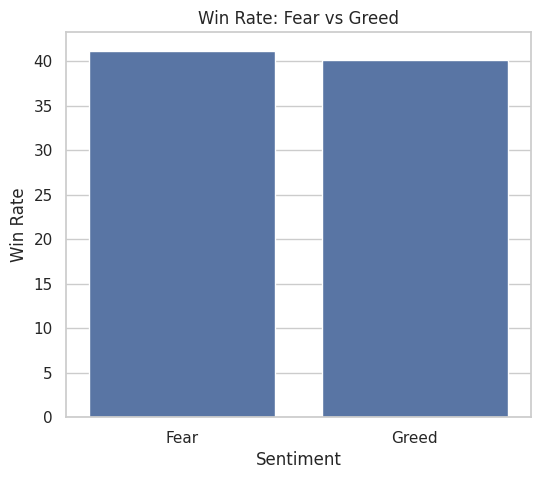

In [27]:
''' (b) Win Rate  '''
sentiment_win = (
    merged.groupby("Sentiment")["Win"]
    .mean()
    .mul(100)
    .reset_index(name="Win Rate")
)

display(sentiment_win)

plt.figure(figsize=(6,5))
sns.barplot(
    data=sentiment_win,
    x="Sentiment",
    y="Win Rate"
)
plt.title("Win Rate: Fear vs Greed")
plt.savefig("outputs/winrate_sentiment.png",dpi=300)
plt.show()

,Sentiment,Worst Loss
0,Fear,-83056.3200
1,Greed,-117990.1041


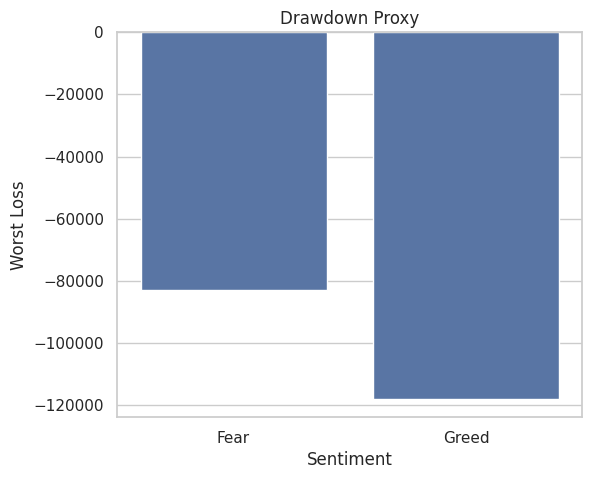

In [28]:
# (c) Drawdown Proxy
drawdown = (
    merged.groupby("Sentiment")
    ["Closed PnL"]
    .min()
    .reset_index(name="Worst Loss")
)

display(drawdown)

plt.figure(figsize=(6,5))
sns.barplot(
    data=drawdown,
    x="Sentiment",
    y="Worst Loss"
)
plt.title("Drawdown Proxy")
plt.savefig("outputs/drawdown.png",dpi=300)
plt.show()

,Sentiment,Trades
0,Fear,92414
1,Greed,28715


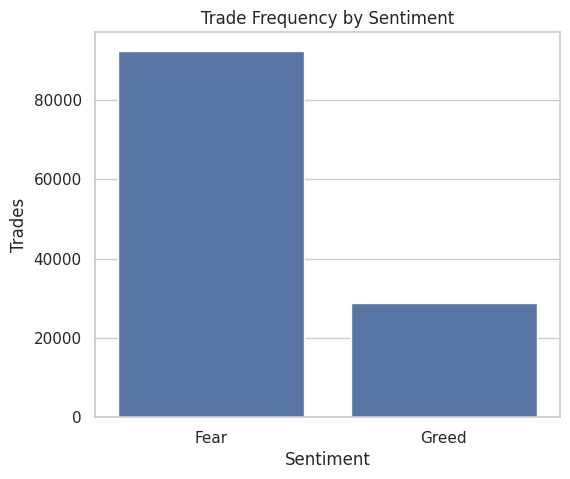

In [29]:
''' 2. Do traders change behavior based on sentiment? '''
''' Trade Frequency '''
trade_frequency = (
    merged.groupby("Sentiment")
    .size()
    .reset_index(name="Trades")
)

display(trade_frequency)

plt.figure(figsize=(6,5))
sns.barplot(
    data=trade_frequency,
    x="Sentiment",
    y="Trades"
)
plt.title("Trade Frequency by Sentiment")
plt.savefig("outputs/trade_frequency.png",dpi=300)
plt.show()


,Sentiment,Size USD
0,Fear,7718.842491
1,Greed,4616.524267


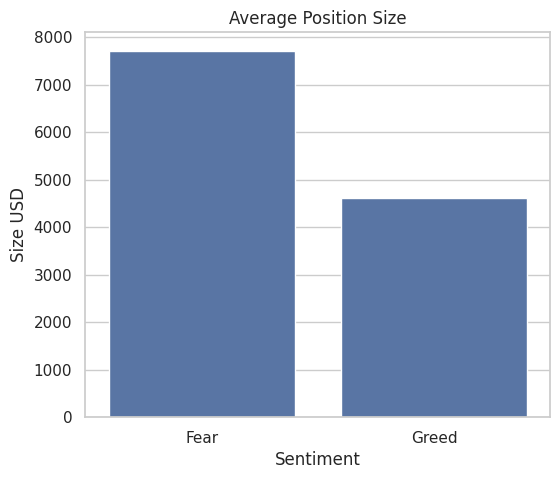

In [36]:
# Position Size
position_size = (
    merged.groupby("Sentiment")
    ["Size USD"]
    .mean()
    .reset_index()
)

display(position_size)

plt.figure(figsize=(6,5))
sns.barplot(
    data=position_size,
    x="Sentiment",
    y="Size USD"
)
plt.title("Average Position Size")
plt.savefig("outputs/position_size.png",dpi=300)
plt.show()

Side,BUY,SELL
Sentiment,,
Fear,47955,44459
Greed,13400,15315


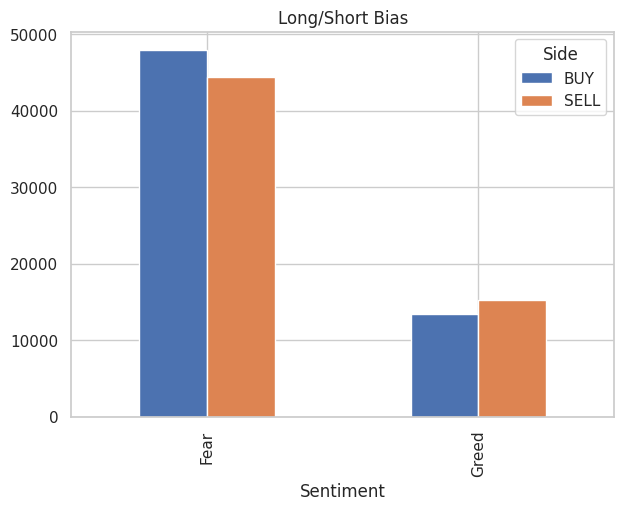

In [37]:
# (c) Long/Short Bias
long_short_bias = pd.crosstab(
    merged["Sentiment"],
    merged["Side"]
)

display(long_short_bias)

long_short_bias.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Long/Short Bias")
plt.savefig("outputs/long_short_bias.png",dpi=300)
plt.show()


,Segment,Count
0,Moderate,9
1,Infrequent,5
2,Frequent,5


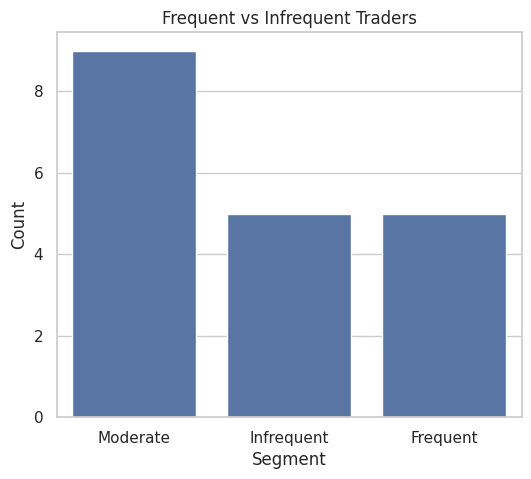

In [38]:
# 3. Segment Analysis
# Segment 1: Frequent vs Infrequent Traders
trader_frequency = (
    merged.groupby("Account")
    .size()
    .reset_index(name="Trades")
)

q1 = trader_frequency["Trades"].quantile(.25)
q3 = trader_frequency["Trades"].quantile(.75)

def segment(x):
    if x >= q3:
        return "Frequent"
    elif x <= q1:
        return "Infrequent"
    return "Moderate"

trader_frequency["Segment"] = (
    trader_frequency["Trades"]
    .apply(segment)
)

segment_summary = (
    trader_frequency["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    "Segment",
    "Count"
]

display(segment_summary)

plt.figure(figsize=(6,5))
sns.barplot(
    data=segment_summary,
    x="Segment",
    y="Count"
)
plt.title("Frequent vs Infrequent Traders")
plt.savefig("outputs/trader_frequency_segment.png",dpi=300)
plt.show()

,Category,Count
0,Inconsistent,11
1,Average,7
2,Consistent Winner,1


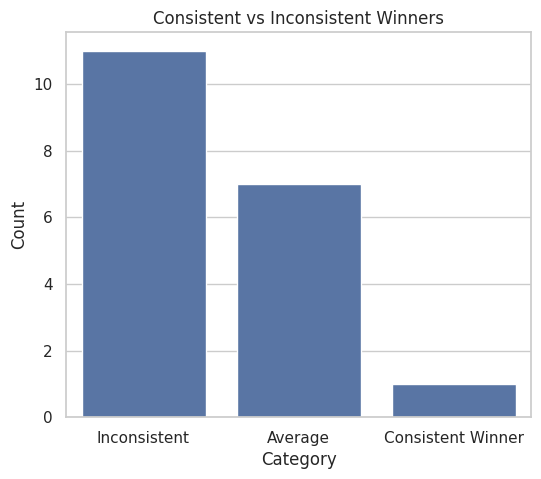

In [39]:
# Segment 2: Consistent vs Inconsistent Winners
winner_segment = win_rate.copy()

winner_segment["Category"] = np.where(
    winner_segment["Win Rate"] >= 60,
    "Consistent Winner",
    np.where(
        winner_segment["Win Rate"] >= 40,
        "Average",
        "Inconsistent"
    )
)

winner_summary = (
    winner_segment["Category"]
    .value_counts()
    .reset_index()
)

winner_summary.columns = [
    "Category",
    "Count"
]

display(winner_summary)

plt.figure(figsize=(6,5))
sns.barplot(
    data=winner_summary,
    x="Category",
    y="Count"
)
plt.title("Consistent vs Inconsistent Winners")
plt.savefig("outputs/winner_categories.png",dpi=300)
plt.show()

# Key Insights

1. Traders exhibited different directional preferences under Fear and Greed market conditions, with Fear periods showing a slightly higher preference for long positions.

2. Most market participants were moderate-frequency traders, while extreme trading frequencies were less common.

3. Only a small fraction of traders demonstrated consistent profitability, indicating that sustained trading success is difficult to achieve.

4. The trader population showed substantial heterogeneity in performance, suggesting that behavioral segmentation can help identify profitable trading patterns.

Part C — “Actionable output”
**bold text**
Strategy 1: Fear Market Strategy

During Fear periods, reduce position sizes and avoid excessive trading to minimize risk and potential losses.

Strategy 2: Greed Market Strategy

During Greed periods, increase trading activity only for traders with a strong historical win rate and maintain disciplined risk management.

Strategy 3: Trade Frequency Strategy

Focus on trade quality rather than quantity, as frequent trading does not necessarily lead to higher profitability.